In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

# Standardize features before distance-based clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit K-Means with 2 clusters (benign/malignant groups)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

# Compare unsupervised clusters with ground-truth labels
print('Confusion Matrix:')
print(confusion_matrix(y, y_kmeans))
print('\nClassification Report:')
print(classification_report(y, y_kmeans))

# Reduce to 2D for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df['Cluster'] = y_kmeans
df['True Label'] = y

Confusion Matrix:
[[ 36 176]
 [339  18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.10      0.17      0.12       212
           1       0.09      0.05      0.07       357

    accuracy                           0.09       569
   macro avg       0.09      0.11      0.09       569
weighted avg       0.09      0.09      0.09       569



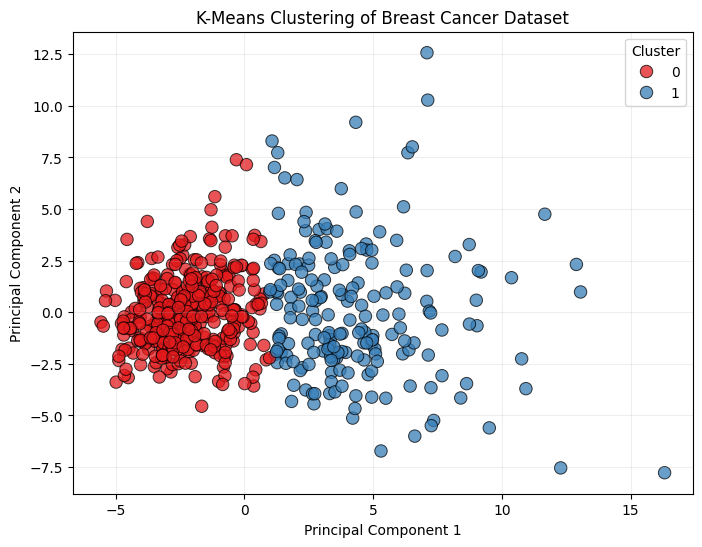

In [3]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='PC1', y='PC2', hue='Cluster',
    palette='Set1', s=80, edgecolor='black', alpha=0.75
)
plt.title('K-Means Clustering of Breast Cancer Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(alpha=0.2)
plt.show()

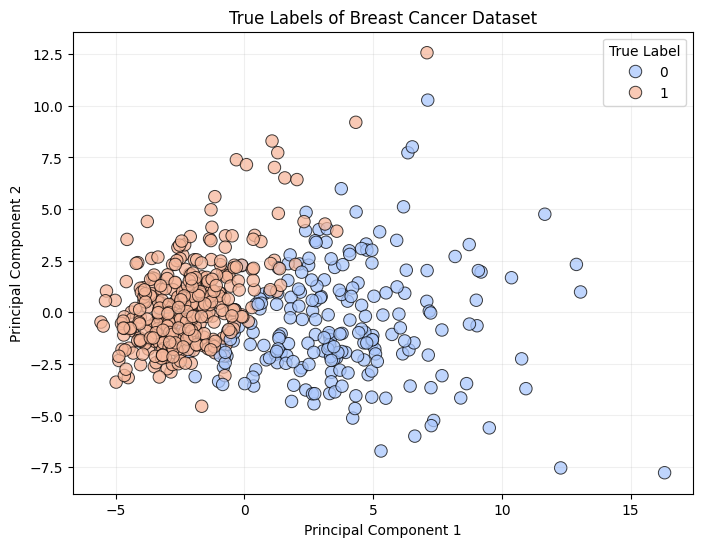

In [4]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='PC1', y='PC2', hue='True Label',
    palette='coolwarm', s=80, edgecolor='black', alpha=0.75
)
plt.title('True Labels of Breast Cancer Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='True Label')
plt.grid(alpha=0.2)
plt.show()

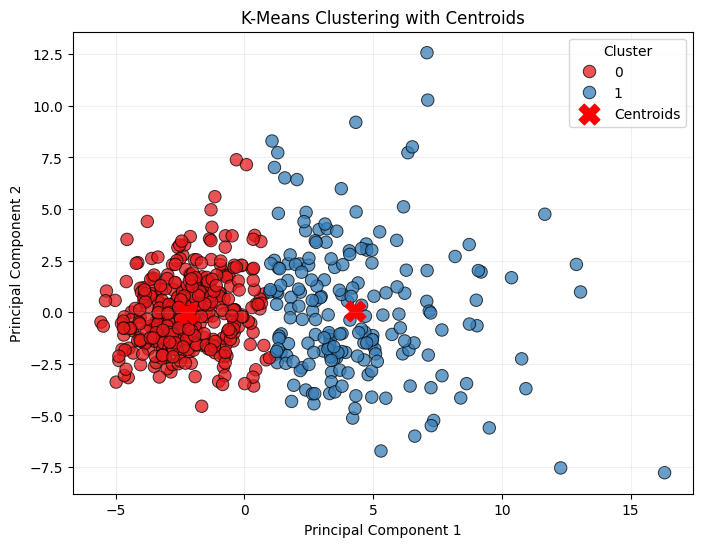

In [5]:
# Plot clusters and mark projected cluster centroids
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='PC1', y='PC2', hue='Cluster',
    palette='Set1', s=80, edgecolor='black', alpha=0.75
)
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], s=220, c='red', marker='X', label='Centroids')
plt.title('K-Means Clustering with Centroids')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(alpha=0.2)
plt.show()